In [2]:
# Import necessary libraries for data analysis and machine learning
# Set up visualization styles and random seed for reproducibility

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr, pearsonr, kendalltau
from scipy.stats import jarque_bera, normaltest
from scipy.cluster import hierarchy
from scipy.ndimage import gaussian_filter1d
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_regression, SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression, Lasso
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [3]:
# Define global constants for analysis parameters
# Sets target horizon, number of features to analyze, and data splitting indices

TARGET_H = '5'
TARGET = f'log_return_{TARGET_H}s'
TOP_N = 30
TRAIN_SPLITS = 5
TEST_DATA_INDEX_BEGIN = 550000

In [4]:
# Load market data from parquet file using fastparquet engine
# Separate price data and feature data for analysis

df = pd.read_parquet("feature.parq", engine="fastparquet")

df_features = df.drop(columns='mid_prc')
returns = df[['mid_prc']].copy()

In [5]:
# Calculate log returns for multiple time horizons (from 1 to 600 seconds)
# Combine returns with features and clean data by removing NaN values

horizons = [1, 5, 10, 30, 60, 120, 300, 600]
for h in horizons:
    returns[f'log_return_{h}s'] = np.log(df['mid_prc']/df['mid_prc'].shift(h)).shift(-h)

data = pd.concat([returns, df_features], axis=1)
data_clean = data.dropna()

feature_cols = [col for col in data_clean.columns if col not in returns.columns]
print(f"Number of features to analyze: {len(feature_cols)}")

Number of features to analyze: 86


In [6]:
# Calculate statistical properties of the target return variable
# Apply tests for normality and report skewness and kurtosis

print(data_clean[TARGET].describe())
print(f"Skewness: {data_clean[TARGET].skew():.4f}")
#Skewness indicates asymmetry of the distribution
print(f"Kurtosis: {data_clean[TARGET].kurtosis():.4f}")
#Kurtosis indicates "tailedness" of the distribution. High values indicate heavy tails.
#Typical Kurtosis value of normal distribution is 3
jb_stat, jb_pval = jarque_bera(data_clean[TARGET].dropna())
print(f"Jarque-Bera test p-value: {jb_pval:.4e}")
#Jarque-Bera test: High value indicates a normal distribution
#Low p-value (< 0.05) indicates non-normality

count    6.037780e+05
mean     8.606939e-07
std      2.510067e-04
min     -1.102941e-02
25%     -8.190014e-05
50%      0.000000e+00
75%      8.248942e-05
max      7.669054e-03
Name: log_return_5s, dtype: float64
Skewness: -0.0905
Kurtosis: 66.8481
Jarque-Bera test p-value: 0.0000e+00


In [7]:
# Compute basic statistical properties of all features
# Calculate mean, standard deviation, skewness and kurtosis for feature analysis

feature_stats = pd.DataFrame({
    'mean': data_clean[feature_cols].mean(),
    'std': data_clean[feature_cols].std(),
    'skew': data_clean[feature_cols].skew(),
    'kurtosis': data_clean[feature_cols].kurtosis(),
})

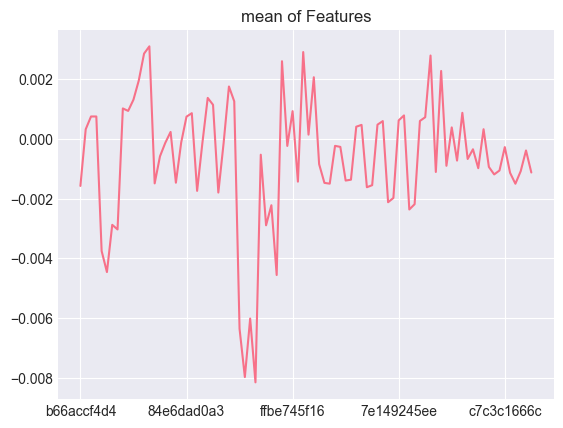

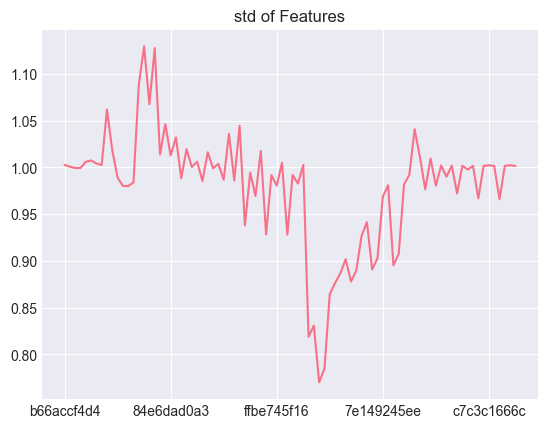

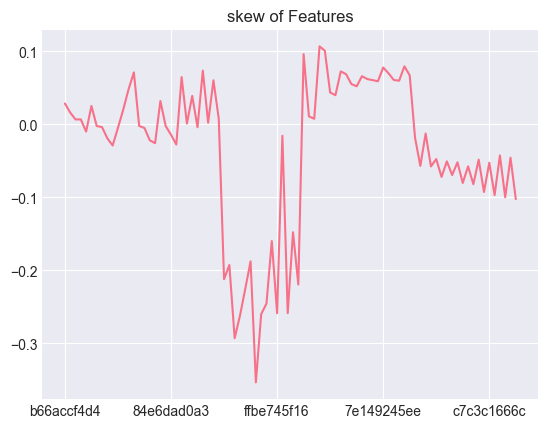

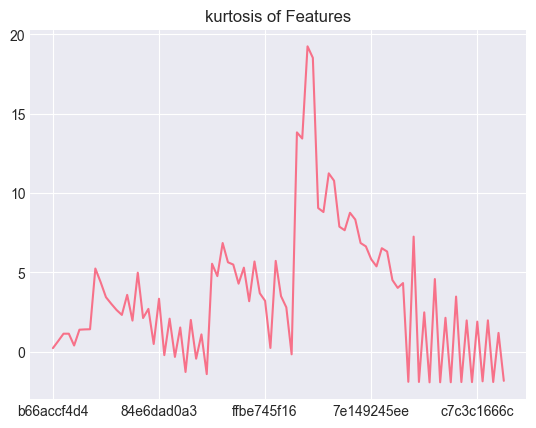

In [8]:
# Visualize the statistical properties of all features
# Create a separate plot for each statistical measure (mean, std, skew, kurtosis)

for col in feature_stats.keys():
    fig = plt.figure()
    feature_stats[col].plot()
    plt.title(f'{col} of Features')

In [9]:
# Identify features with extreme statistical properties
# Find top 10 features by standard deviation, skewness, and kurtosis

print("\nTop 10 features by standard deviation:")
print(feature_stats.nlargest(10, 'std')[['mean', 'std', 'skew']])
top_10_std = set(feature_stats.nlargest(10, 'std').index)

print("\nMost skewed features (abs value):")
feature_stats['abs_skew'] = feature_stats['skew'].abs()
print(feature_stats.nlargest(10, 'abs_skew')[['skew', 'kurtosis']])
top_10_absSkew = set(feature_stats.nlargest(10, 'abs_skew').index)


print("\nMost heavy tailed features:")
print(feature_stats.nlargest(10, 'kurtosis'))
top_10_kurtosis = set(feature_stats.nlargest(10, 'kurtosis').index)


Top 10 features by standard deviation:
                mean       std      skew
5e7e5a691e -0.000586  1.129732 -0.005049
c12d090869  0.000231  1.127843 -0.025863
e10ab80234 -0.001493  1.088837 -0.002257
ec021e3c39 -0.000134  1.067702 -0.021939
134e1a6937  0.001018  1.062088 -0.019210
5e95d4c57f -0.000122  1.046479 -0.002474
f46c65222f -0.008160  1.044726 -0.262114
c2675078fe  0.002792  1.040911 -0.018196
98727525fc -0.007983  1.036171 -0.192646
72e0d3737a  0.000859  1.032300 -0.027679

Most skewed features (abs value):
                skew  kurtosis
d5b6b02144 -0.353439  5.290576
4a9f632715 -0.292985  6.842736
f46c65222f -0.262114  5.627556
da2cdd99f0 -0.260109  3.174002
ffbe745f16 -0.258785  3.197076
a4e012f275 -0.258627  5.716558
f2541b5abc -0.245421  5.677217
ac8a9f9f8f -0.225311  5.484018
be3e28c4c3 -0.219380  2.786105
d50ec44f62 -0.212137  5.536256

Most heavy tailed features:
                mean       std      skew   kurtosis  abs_skew
299afc361e -0.000236  0.769869  0.106794  

In [10]:
# Combine features with extreme statistical properties
# Create a list of top volatile features for further analysis

TOP_VOL_FEATURES = list(top_10_std.union(top_10_absSkew).union(top_10_kurtosis))

In [11]:
# Calculate correlation matrices between top volatile features and returns
# Generate separate correlation matrices for each time horizon

top_vol_features_corr_matrix = {}

for h in horizons:
    top_vol_features_corr_matrix[h] = data_clean[TOP_VOL_FEATURES + [f'log_return_{h}s']].corr()

In [12]:
# Calculate correlation matrices between all features and returns
# Generate separate correlation matrices for each time horizon

all_features_corr_matrix = {}

for h in horizons:
    all_features_corr_matrix[h] = data_clean[feature_cols + [f'log_return_{h}s']].corr()

Text(0, 0.5, 'Std Dev')

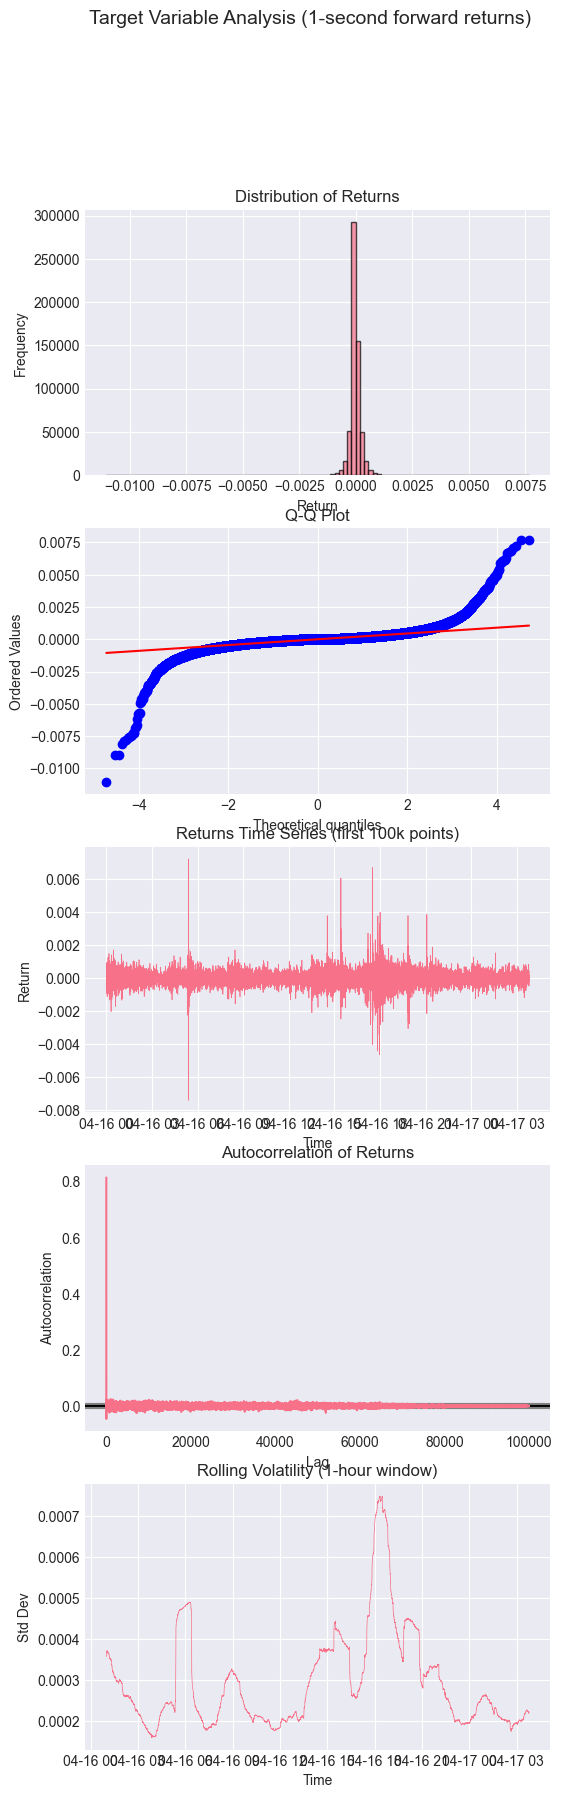

In [13]:
# Perform comprehensive visual analysis of the target variable
# Create multiple plots including distribution, Q-Q plot, time series and volatility

SAMPLE_SIZE = 100000 # First 100k points for visibility
ROLLING_VOL_WINDOW = 3600 # 1-hour rolling

fig, axes = plt.subplots(5, 1, figsize=(6, 20))
fig.suptitle('Target Variable Analysis (1-second forward returns)', fontsize=14)

axes[0].hist(data_clean[TARGET].dropna(), bins=100, edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Returns')
axes[0].set_xlabel('Return')
axes[0].set_ylabel('Frequency')

# Q-Q plot
stats.probplot(data_clean[TARGET].dropna(), dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot')

# Time series
sample_data = data_clean[TARGET].iloc[:SAMPLE_SIZE]  
axes[2].plot(sample_data.index, sample_data.values, linewidth=0.5)
axes[2].set_title(f'Returns Time Series (first {SAMPLE_SIZE//1000}k points)')
axes[2].set_xlabel('Time')
axes[2].set_ylabel('Return')

# Autocorrelation
from pandas.plotting import autocorrelation_plot
autocorrelation_plot(data_clean[TARGET].dropna().iloc[:SAMPLE_SIZE], ax=axes[3])
axes[3].set_title('Autocorrelation of Returns')

# Rolling volatility
rolling_vol = data_clean[TARGET].rolling(window=ROLLING_VOL_WINDOW).std()  
axes[4].plot(rolling_vol.index[:SAMPLE_SIZE], rolling_vol.values[:SAMPLE_SIZE], linewidth=0.5)
axes[4].set_title('Rolling Volatility (1-hour window)')
axes[4].set_xlabel('Time')
axes[4].set_ylabel('Std Dev')

In [14]:
# Calculate correlations between features and target variables
# Find top correlated features using both Pearson and Spearman methods

print("\n1.4 Feature Correlation Analysis with Target")
print("-" * 40)

best_feats = {}

for h in horizons:
    target = f'log_return_{h}s'
    best_feats[h] = set()
    correlations = pd.DataFrame({
        'pearson': [pearsonr(data_clean[col].dropna(), 
                            data_clean.loc[data_clean[col].notna(), target])[0] 
                    for col in feature_cols],
        'spearman': [spearmanr(data_clean[col].dropna(), 
                            data_clean.loc[data_clean[col].notna(), target])[0] 
                    for col in feature_cols]
    }, index=feature_cols)

    correlations['abs_pearson'] = correlations['pearson'].abs()
    correlations['abs_spearman'] = correlations['spearman'].abs()

    print(f"\nTop {TOP_N} features by Pearson correlation (absolute value) for horizon {h}s")
    print(correlations.nlargest(TOP_N, 'abs_pearson')[['pearson', 'spearman']])
    best_feats[h].update(correlations.nlargest(TOP_N, 'abs_pearson').index)

    print(f"\nTop {TOP_N} features by Spearman correlation (absolute value): for horizon {h}s")
    print(correlations.nlargest(TOP_N, 'abs_spearman')[['spearman', 'pearson']])
    best_feats[h].update(correlations.nlargest(TOP_N, 'abs_spearman').index)


1.4 Feature Correlation Analysis with Target
----------------------------------------

Top 30 features by Pearson correlation (absolute value) for horizon 1s
             pearson  spearman
5e7e5a691e  0.121843  0.209311
e10ab80234  0.119239  0.209072
5e95d4c57f  0.116673  0.203060
ac567aa14a  0.113478  0.202641
c12d090869  0.111585  0.200093
ec021e3c39  0.108221  0.199823
497584e7d1  0.102905  0.178983
9c51f3cf1d  0.102681  0.178840
b66accf4d4  0.101830  0.159973
865224234b  0.100244  0.178243
e093f74611  0.100032  0.174141
e486088bae  0.097420  0.173322
f46c65222f  0.091777  0.159525
98727525fc  0.090851  0.152215
4a9f632715  0.090260  0.158787
d50ec44f62  0.089505  0.151557
c2675078fe  0.087217  0.162664
706dbe6d28  0.085054  0.154328
72e0d3737a  0.080046  0.149699
84e6dad0a3  0.079586  0.149549
d4112c20e5  0.077358  0.140411
ac8a9f9f8f  0.075577  0.139386
e2624a64cd  0.074406  0.126961
01d830fc33  0.073780  0.109760
301f8d1b44  0.070942  0.127256
cb232e1c9f  0.069957  0.127183
134e

In [15]:
# Save best features identified by correlation analysis
# Store for later use in feature selection and model building

TOP_BEST_FEATS_BY_CORR = best_feats.copy()

In [16]:
# Compare feature selection across different time horizons
# Analyze overlap in top features between pairs of horizons

i = 0

while i < len(horizons):
    j = i+1
    while j < len(horizons):
        h_i, h_j = horizons[i],horizons[j]
        print(f"Common TOP FEATURES BETWEEN HORIZON {h_i}s and HORIZON {h_j}s = ", len(TOP_BEST_FEATS_BY_CORR[h_i].intersection(TOP_BEST_FEATS_BY_CORR[h_j])))
        j+=1
    i+=1

Common TOP FEATURES BETWEEN HORIZON 1s and HORIZON 5s =  28
Common TOP FEATURES BETWEEN HORIZON 1s and HORIZON 10s =  30
Common TOP FEATURES BETWEEN HORIZON 1s and HORIZON 30s =  28
Common TOP FEATURES BETWEEN HORIZON 1s and HORIZON 60s =  23
Common TOP FEATURES BETWEEN HORIZON 1s and HORIZON 120s =  20
Common TOP FEATURES BETWEEN HORIZON 1s and HORIZON 300s =  18
Common TOP FEATURES BETWEEN HORIZON 1s and HORIZON 600s =  8
Common TOP FEATURES BETWEEN HORIZON 5s and HORIZON 10s =  32
Common TOP FEATURES BETWEEN HORIZON 5s and HORIZON 30s =  31
Common TOP FEATURES BETWEEN HORIZON 5s and HORIZON 60s =  25
Common TOP FEATURES BETWEEN HORIZON 5s and HORIZON 120s =  22
Common TOP FEATURES BETWEEN HORIZON 5s and HORIZON 300s =  19
Common TOP FEATURES BETWEEN HORIZON 5s and HORIZON 600s =  9
Common TOP FEATURES BETWEEN HORIZON 10s and HORIZON 30s =  31
Common TOP FEATURES BETWEEN HORIZON 10s and HORIZON 60s =  25
Common TOP FEATURES BETWEEN HORIZON 10s and HORIZON 120s =  22
Common TOP FEATUR

In [17]:
# Detect non-linear relationships between features and target
# Use Random Forest importance as a proxy for non-linear feature importance

# 1.7 Non-linear Relationship Detection
print("\n1.7 Non-linear Relationship Analysis")
print("-" * 40)

# Using Random Forest feature importance as proxy for non-linear relationships
rf_model = RandomForestRegressor(n_estimators=100, 
                                 max_depth=6, 
                                 random_state=RANDOM_STATE,
                                 n_jobs=-1)

X_sample = data_clean[feature_cols].iloc[:300000]
y_sample = data_clean[TARGET].iloc[:300000]

rf_model.fit(X_sample, y_sample)

# Feature importance
rf_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nTop {TOP_N} features by Random Forest importance (non-linear):")
print(rf_importance.head(TOP_N))

# Compare linear vs non-linear importance
importance_comparison = pd.merge(
    correlations[['abs_spearman']].reset_index(),
    rf_importance,
    left_on='index',
    right_on='feature'
)
importance_comparison['linear_rank'] = importance_comparison['abs_spearman'].rank(ascending=False)
importance_comparison['nonlinear_rank'] = importance_comparison['importance'].rank(ascending=False)
importance_comparison['rank_diff'] = abs(importance_comparison['linear_rank'] - 
                                        importance_comparison['nonlinear_rank'])

print("\nFeatures with largest difference between linear and non-linear importance:")
print(importance_comparison.nlargest(TOP_N, 'rank_diff')[['feature', 'linear_rank', 
                                                        'nonlinear_rank', 'rank_diff']])


1.7 Non-linear Relationship Analysis
----------------------------------------

Top 30 features by Random Forest importance (non-linear):
       feature  importance
0   b66accf4d4    0.139142
14  e10ab80234    0.083150
4   9c51f3cf1d    0.061487
15  5e7e5a691e    0.054261
13  486b27acac    0.054238
12  8572904679    0.046251
1   01d830fc33    0.036426
6   cb232e1c9f    0.032985
21  72e0d3737a    0.025481
7   301f8d1b44    0.025144
11  c910253362    0.024932
5   706dbe6d28    0.024573
3   86eecbe036    0.016577
10  d182b35ca9    0.015550
2   ac29aa28b0    0.012306
84  486cb65b0c    0.012145
16  ec021e3c39    0.011421
25  7d08e345ba    0.011185
8   134e1a6937    0.011051
18  ac567aa14a    0.010936
76  2d1cf32644    0.009671
80  c7c3c1666c    0.009062
81  73762306aa    0.008734
28  7a0f3d15e0    0.007941
83  0d19cb3fb0    0.007669
77  18af9014b6    0.007573
29  7373db20a8    0.007564
19  5e95d4c57f    0.007518
20  84e6dad0a3    0.007499
9   5f3f783a1f    0.007275

Features with largest di

In [18]:
# Select top features based on non-linear importance
# Extract features with highest Random Forest importance scores

TOP_NONLINEAR_FEAT = set(importance_comparison[['index', 'importance']].sort_values(by='importance', ascending=False).head(TOP_N)['index'].values)

In [19]:
# Analyze feature correlations across different prediction horizons
# Calculate Spearman correlations between features and returns for each time horizon

print("\n" + "="*60)
print("PART 2: PREDICTION HORIZON ANALYSIS")
print("="*60)

top_features = correlations.nlargest(TOP_N, 'abs_spearman').index.tolist()

print(f"\nAnalyzing top {TOP_N} features across different horizons")

horizon_correlations = {}
for h in horizons:
    target_col = f'log_return_{h}s'
    if target_col in data_clean.columns:
        horizon_corr = []
        for feat in top_features:
            corr, _ = spearmanr(data_clean[feat].dropna(),
                               data_clean.loc[data_clean[feat].notna(), target_col])
            horizon_corr.append(corr)
        horizon_correlations[h] = horizon_corr

horizon_df = pd.DataFrame(horizon_correlations, index=top_features)


PART 2: PREDICTION HORIZON ANALYSIS

Analyzing top 30 features across different horizons


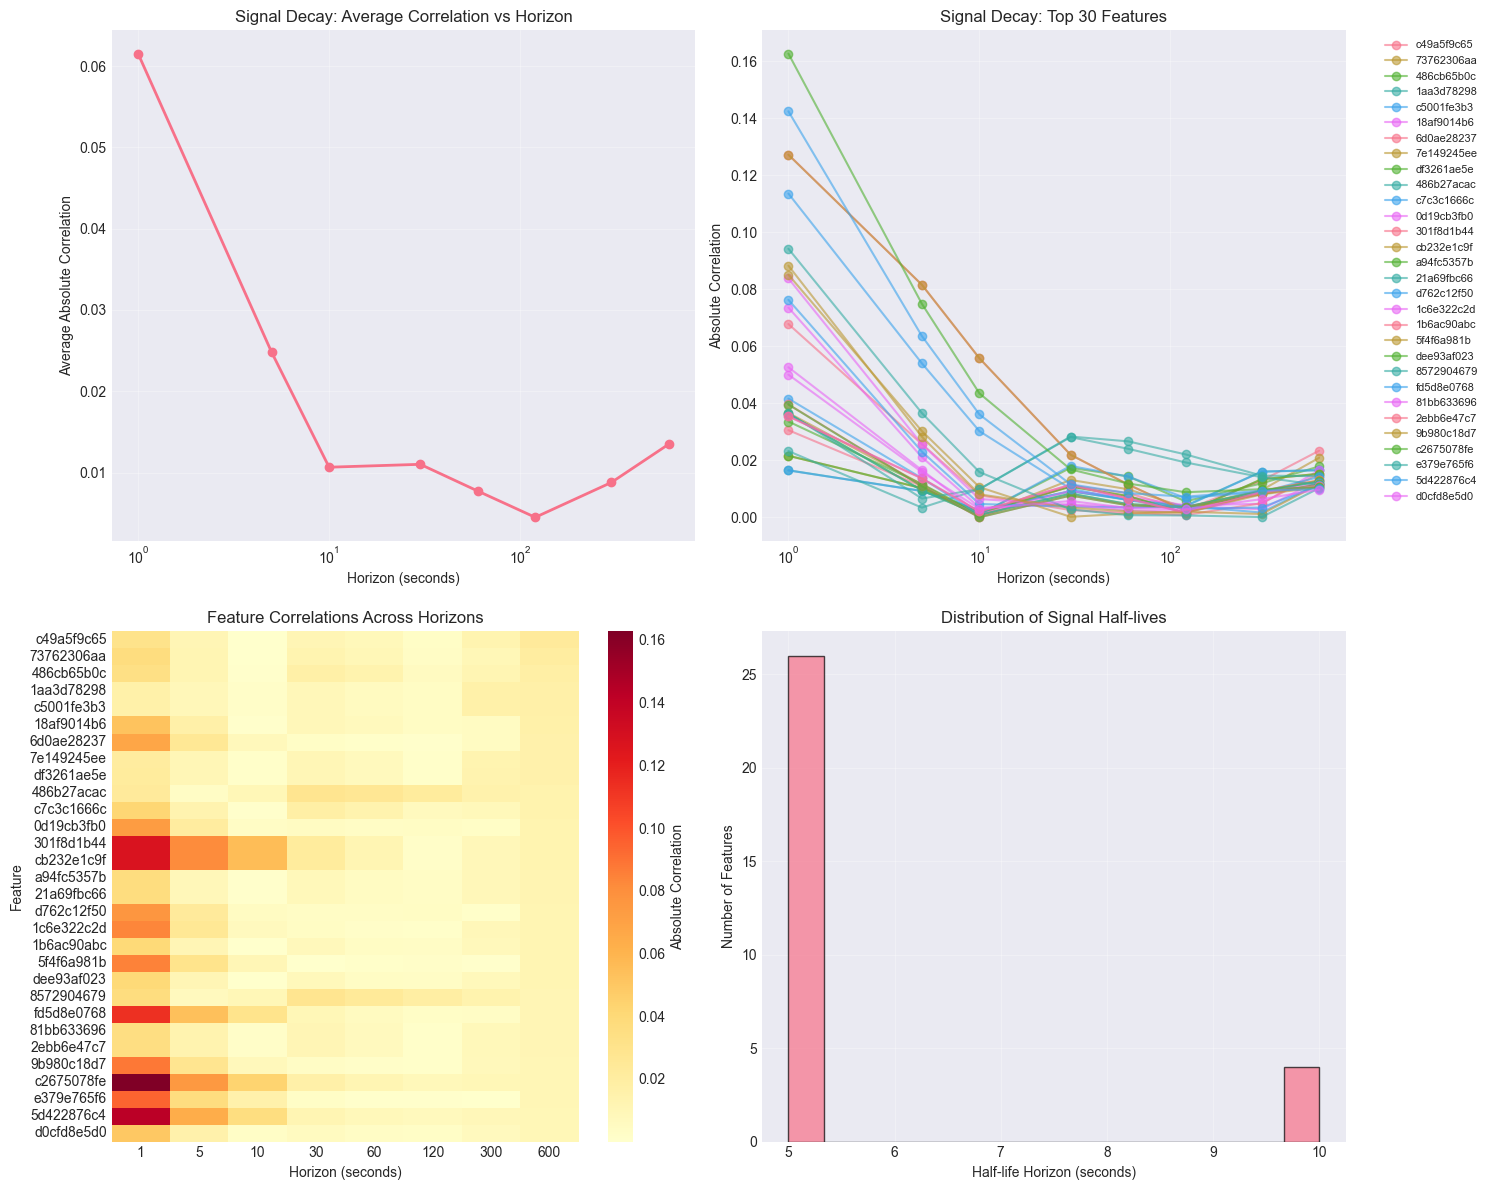


Signal Decay Analysis:
Average correlation at 1s: 0.0615
Average correlation at 60s: 0.0077
Average correlation at 600s: 0.0135
Decay ratio (60s/1s): 12.54%
Median signal half-life: 5 seconds


In [20]:
# Visualize signal decay patterns across different time horizons
# Analyze how feature predictive power decays with increasing prediction horizon

# Visualize signal decay
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Average correlation decay
avg_corr = horizon_df.abs().mean()
axes[0, 0].plot(horizons, avg_corr.values, marker='o', linewidth=2)
axes[0, 0].set_xlabel('Horizon (seconds)')
axes[0, 0].set_ylabel('Average Absolute Correlation')
axes[0, 0].set_title('Signal Decay: Average Correlation vs Horizon')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xscale('log')

# Individual feature decay
for feat in top_features[:TOP_N]:
    axes[0, 1].plot(horizons, horizon_df.loc[feat].abs().values, 
                   marker='o', alpha=0.6, label=feat)
axes[0, 1].set_xlabel('Horizon (seconds)')
axes[0, 1].set_ylabel('Absolute Correlation')
axes[0, 1].set_title(f'Signal Decay: Top {TOP_N} Features')
axes[0, 1].set_xscale('log')
axes[0, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[0, 1].grid(True, alpha=0.3)

# Heatmap of correlations
sns.heatmap(horizon_df.abs(), 
            xticklabels=horizons,
            yticklabels=top_features,
            cmap='YlOrRd',
            ax=axes[1, 0],
            cbar_kws={'label': 'Absolute Correlation'})
axes[1, 0].set_xlabel('Horizon (seconds)')
axes[1, 0].set_ylabel('Feature')
axes[1, 0].set_title('Feature Correlations Across Horizons')

# Half-life analysis
half_life_horizons = []
for feat in top_features:
    initial_corr = abs(horizon_df.loc[feat, 1])
    half_corr = initial_corr / 2
    
    for h in horizons:
        if abs(horizon_df.loc[feat, h]) < half_corr:
            half_life_horizons.append(h)
            break
    else:
        half_life_horizons.append(horizons[-1])

axes[1, 1].hist(half_life_horizons, bins=15, edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Half-life Horizon (seconds)')
axes[1, 1].set_ylabel('Number of Features')
axes[1, 1].set_title('Distribution of Signal Half-lives')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nSignal Decay Analysis:")
print(f"Average correlation at 1s: {avg_corr[1]:.4f}")
print(f"Average correlation at 60s: {avg_corr[60]:.4f}")
print(f"Average correlation at 600s: {avg_corr[600]:.4f}")
print(f"Decay ratio (60s/1s): {avg_corr[60]/avg_corr[1]:.2%}")
print(f"Median signal half-life: {np.median(half_life_horizons):.0f} seconds")

In [21]:
# Determine optimal prediction horizon using signal-to-noise ratio
# Compare predictive power across different time horizons

# Optimal horizon selection
print("\n2.1 Optimal Horizon Selection")
print("-" * 40)

# Calculate signal-to-noise ratio for each horizon
snr_by_horizon = {}
for h in horizons:
    target_col = f'log_return_{h}s'
    if target_col in data_clean.columns:

        X = data_clean[list(TOP_BEST_FEATS_BY_CORR[h].union(TOP_NONLINEAR_FEAT))]
        y = data_clean[target_col]
        
        model = Ridge(alpha=1.0)
        model.fit(X.iloc[:SAMPLE_SIZE], y.iloc[:SAMPLE_SIZE])
        y_pred = model.predict(X.iloc[SAMPLE_SIZE:])
        
        signal_var = np.var(y_pred)
        noise_var = np.var(y.iloc[SAMPLE_SIZE:] - y_pred)
        snr = signal_var / noise_var if noise_var > 0 else 0
        snr_by_horizon[h] = snr

print("\nSignal-to-Noise Ratio by Horizon:")
for h, snr in snr_by_horizon.items():
    print(f"  {h:3d}s: SNR = {snr:.6f}")

optimal_horizon = max(snr_by_horizon, key=snr_by_horizon.get)
print(f"\nOptimal horizon based on SNR: {optimal_horizon} seconds")


2.1 Optimal Horizon Selection
----------------------------------------

Signal-to-Noise Ratio by Horizon:
    1s: SNR = 0.061864
    5s: SNR = 0.020988
   10s: SNR = 0.018585
   30s: SNR = 0.013106
   60s: SNR = 0.014188
  120s: SNR = 0.017841
  300s: SNR = 0.030062
  600s: SNR = 0.057839

Optimal horizon based on SNR: 1 seconds


In [22]:
# Prepare data for model training and evaluation
# Split data into training and test sets using selected features

SAMPLE_SIZE = 500000
selected_cols = list(TOP_BEST_FEATS_BY_CORR[h].union(TOP_NONLINEAR_FEAT))
X = data_clean[selected_cols]
y = data_clean[TARGET]

X_train, X_test, y_train, y_test = X.iloc[:SAMPLE_SIZE], X.iloc[SAMPLE_SIZE:], y.iloc[:SAMPLE_SIZE], y.iloc[SAMPLE_SIZE:]


PART 3: PCA & DIMENSIONALITY REDUCTION

PCA Results:
Components needed for 90% variance: 7
Components needed for 95% variance: 10
Components needed for 99% variance: 21


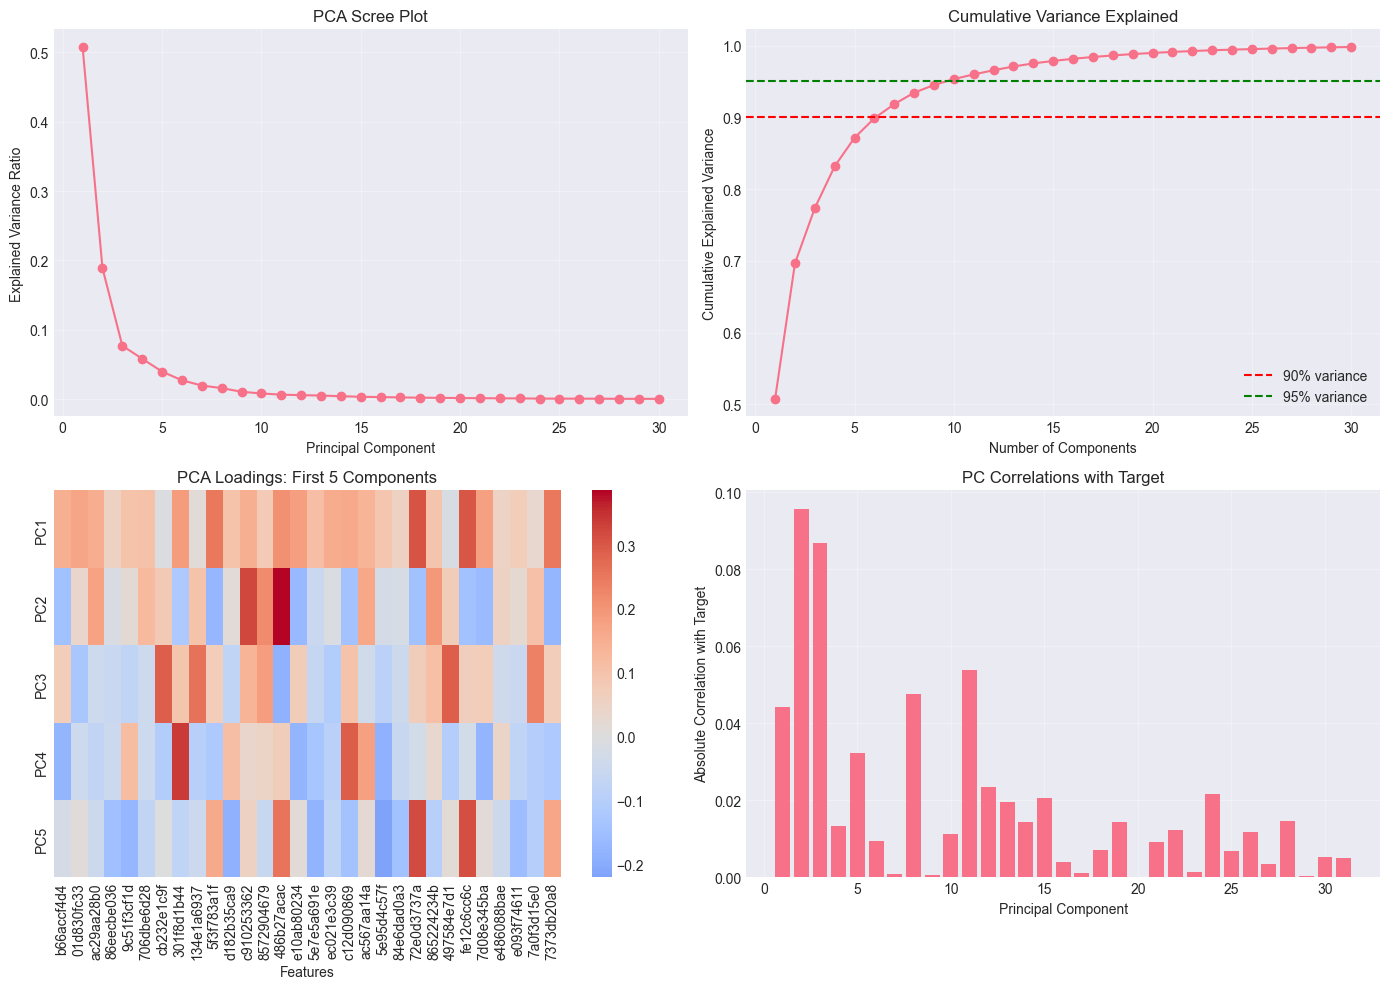

In [23]:
# Perform Principal Component Analysis (PCA) for dimensionality reduction
# Analyze explained variance and component loadings

TOP_LOADINGS = 5

print("\n" + "="*60)
print("PART 3: PCA & DIMENSIONALITY REDUCTION")
print("="*60)

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_train)

# Perform PCA
pca = PCA(random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

# Analyze PCA results
cumsum_var = np.cumsum(pca.explained_variance_ratio_)
n_components_90 = np.argmax(cumsum_var >= 0.90) + 1
n_components_95 = np.argmax(cumsum_var >= 0.95) + 1
n_components_99 = np.argmax(cumsum_var >= 0.99) + 1

print(f"\nPCA Results:")
print(f"Components needed for 90% variance: {n_components_90}")
print(f"Components needed for 95% variance: {n_components_95}")
print(f"Components needed for 99% variance: {n_components_99}")

# Visualize PCA results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Scree plot
axes[0, 0].plot(range(1, min(TOP_N+1, len(pca.explained_variance_ratio_)+1)), 
               pca.explained_variance_ratio_[:TOP_N], 
               marker='o')
axes[0, 0].set_xlabel('Principal Component')
axes[0, 0].set_ylabel('Explained Variance Ratio')
axes[0, 0].set_title('PCA Scree Plot')
axes[0, 0].grid(True, alpha=0.3)

# Cumulative variance
axes[0, 1].plot(range(1, min(TOP_N+1, len(cumsum_var)+1)), 
               cumsum_var[:TOP_N], 
               marker='o')
axes[0, 1].axhline(y=0.90, color='r', linestyle='--', label='90% variance')
axes[0, 1].axhline(y=0.95, color='g', linestyle='--', label='95% variance')
axes[0, 1].set_xlabel('Number of Components')
axes[0, 1].set_ylabel('Cumulative Explained Variance')
axes[0, 1].set_title('Cumulative Variance Explained')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

loadings = pca.components_[:TOP_LOADINGS, :TOP_N] 
sns.heatmap(loadings, 
            xticklabels=feature_cols[:TOP_N],
            yticklabels=[f'PC{i+1}' for i in range(TOP_LOADINGS)],
            cmap='coolwarm',
            center=0,
            ax=axes[1, 0])
axes[1, 0].set_title(f'PCA Loadings: First {TOP_LOADINGS} Components')
axes[1, 0].set_xlabel('Features')

# Correlation of PCs with target
pc_correlations = []
for i in range(min(TOP_N+1, X_pca.shape[1])):
    corr, _ = spearmanr(X_pca[:, i], y_train)
    pc_correlations.append(abs(corr))

axes[1, 1].bar(range(1, len(pc_correlations)+1), pc_correlations)
axes[1, 1].set_xlabel('Principal Component')
axes[1, 1].set_ylabel('Absolute Correlation with Target')
axes[1, 1].set_title('PC Correlations with Target')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
# Build and evaluate a linear composite signal (alpha model)
# Train Ridge regression model on PCA-reduced features

print("\n" + "="*60)
print("PART 4: COMPOSITE SIGNAL & PREDICTIVE MODEL")
print("="*60)

TARGET = 'log_return_5s'
SAMPLE_SIZE = 500000
selected_cols = list(TOP_BEST_FEATS_BY_CORR[h].union(TOP_NONLINEAR_FEAT))
X = data_clean[selected_cols]
y = data_clean[TARGET]

X_train, X_test, y_train, y_test = X.iloc[:SAMPLE_SIZE], X.iloc[SAMPLE_SIZE:], y.iloc[:SAMPLE_SIZE], y.iloc[SAMPLE_SIZE:]

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca_reduced = PCA(n_components=n_components_90, random_state=RANDOM_STATE)
X_train_pca_reduced = pca_reduced.fit_transform(X_train_scaled)
X_test_pca_reduced = pca_reduced.transform(X_test_scaled)

print(f"\nReduced from {len(feature_cols)} to {n_components_95} principal components")
print(f"Variance retained: {pca_reduced.explained_variance_ratio_.sum():.2%}")

tscv = TimeSeriesSplit(n_splits=5)

print("\n4.1 Linear Composite Signal")
print("-" * 40)

# Ridge regression for stability
ridge_model = Ridge(alpha=0.9)
ridge_scores = cross_val_score(ridge_model, X_train_pca_reduced, y_train, 
                               cv=tscv, scoring='r2', n_jobs=-1)
print(f"Ridge R² scores: {ridge_scores}")
print(f"Mean R²: {ridge_scores.mean():.6f} (+/- {ridge_scores.std():.6f})")

ridge_model.fit(X_train_pca_reduced, y_train)

signal_test = ridge_model.predict(X_test_pca_reduced)

print(r2_score(y_test.values, signal_test))


PART 4: COMPOSITE SIGNAL & PREDICTIVE MODEL

Reduced from 86 to 10 principal components
Variance retained: 91.85%

4.1 Linear Composite Signal
----------------------------------------
Ridge R² scores: [0.00856298 0.02138108 0.02044421 0.01883912 0.00534391]
Mean R²: 0.014914 (+/- 0.006629)
0.003710031509399414


Out-of-Sample Annualized Sharpe Ratio: -22.18


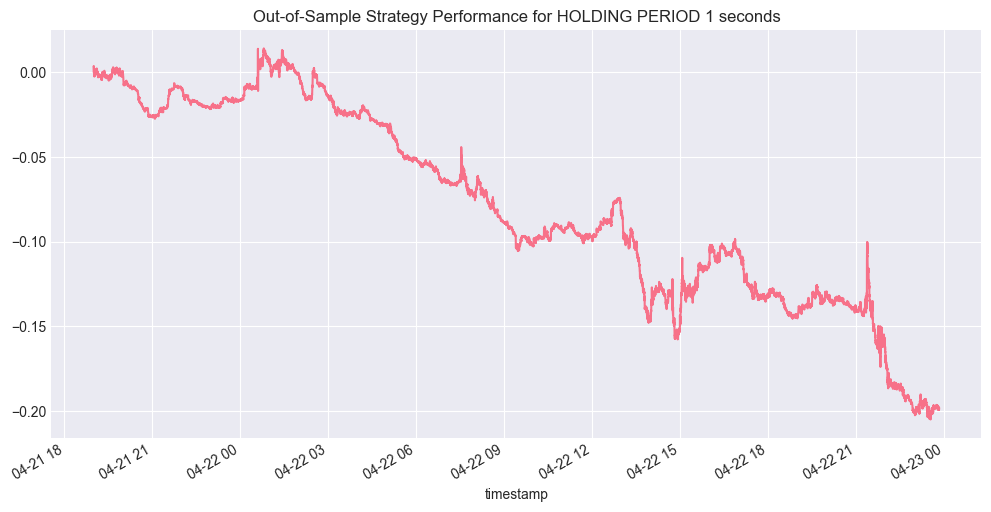

Out-of-Sample Annualized Sharpe Ratio: 2.01


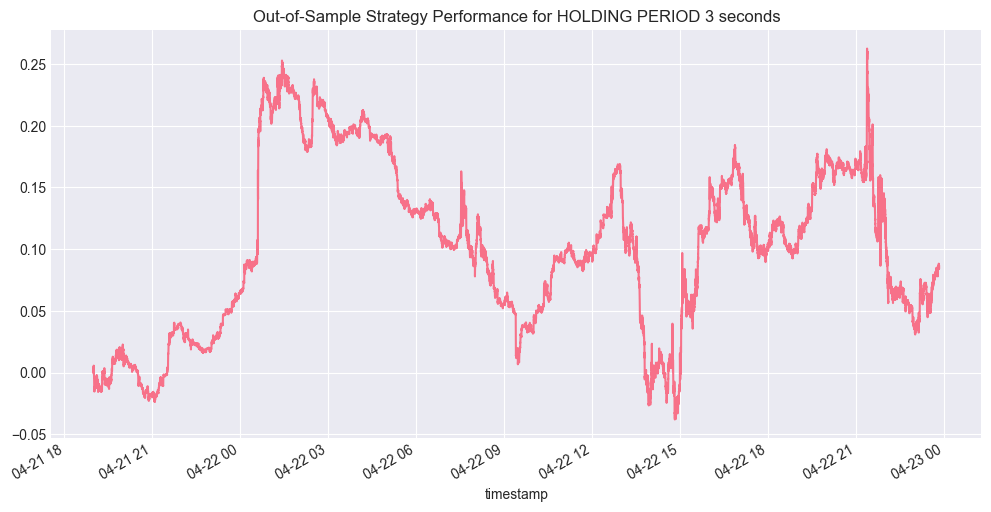

Out-of-Sample Annualized Sharpe Ratio: 2.95


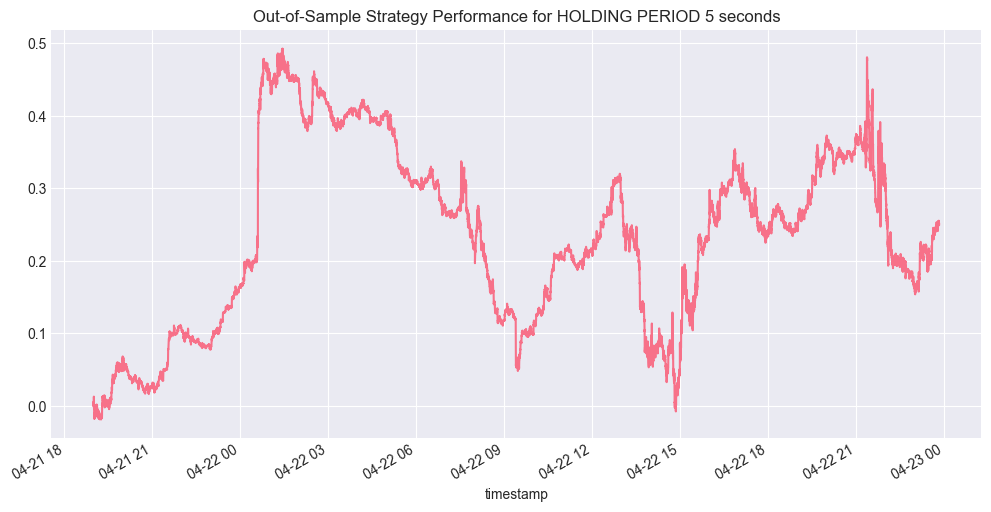

Out-of-Sample Annualized Sharpe Ratio: 3.83


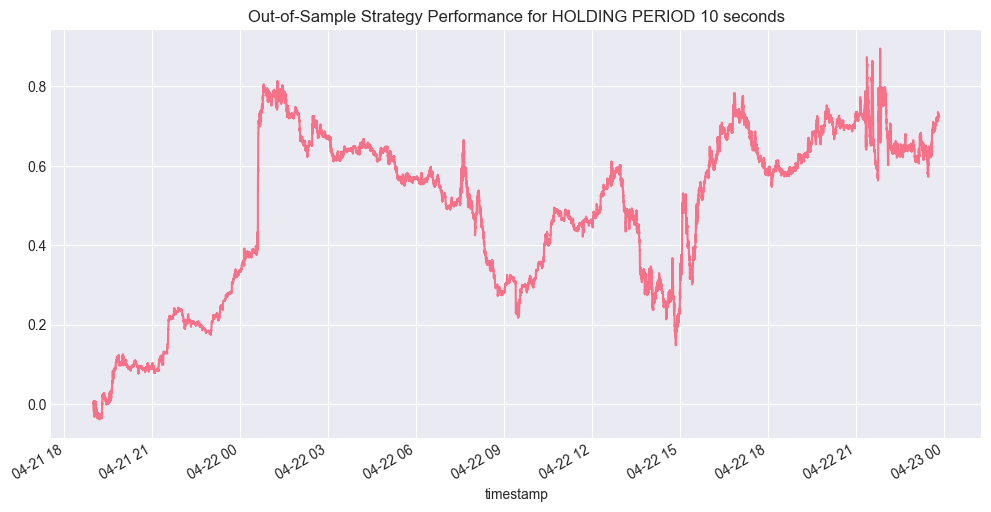

Out-of-Sample Annualized Sharpe Ratio: 3.29


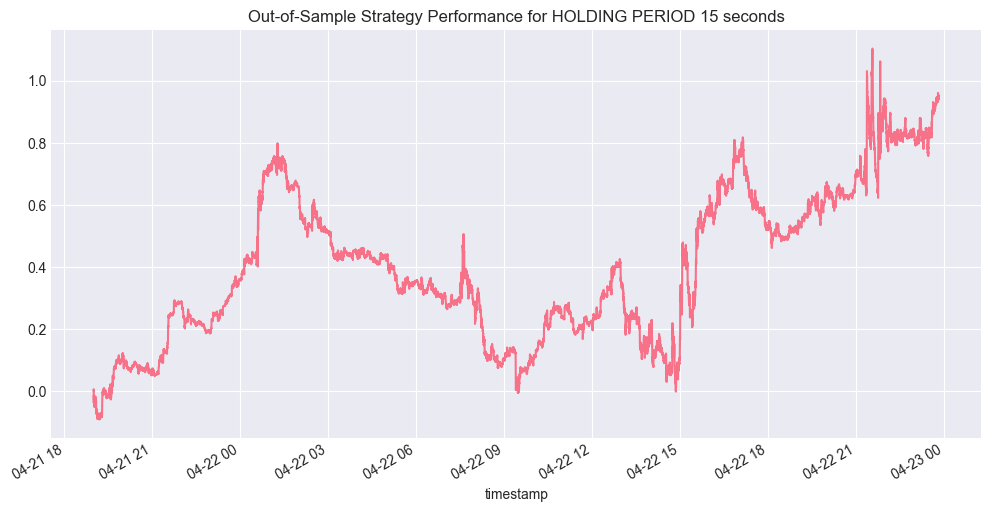

Out-of-Sample Annualized Sharpe Ratio: 2.50


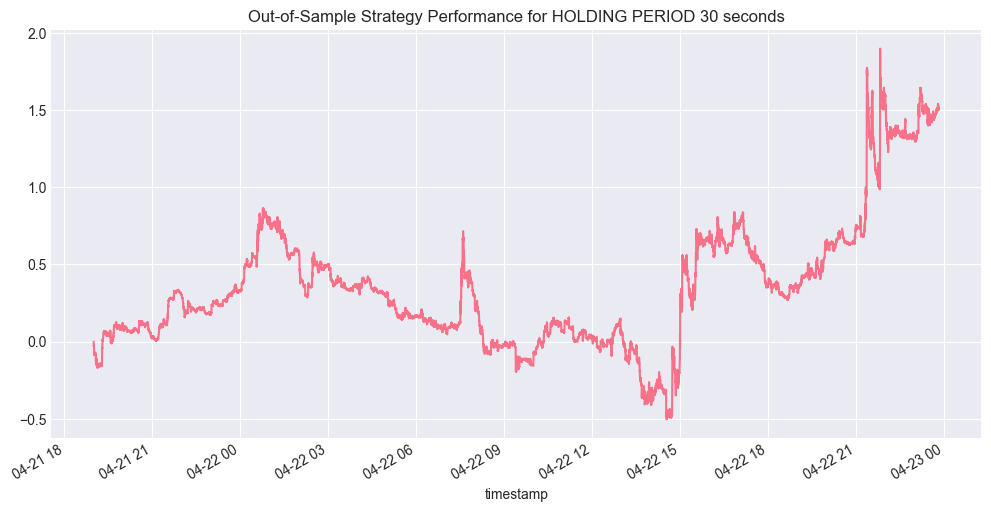

Out-of-Sample Annualized Sharpe Ratio: 2.80


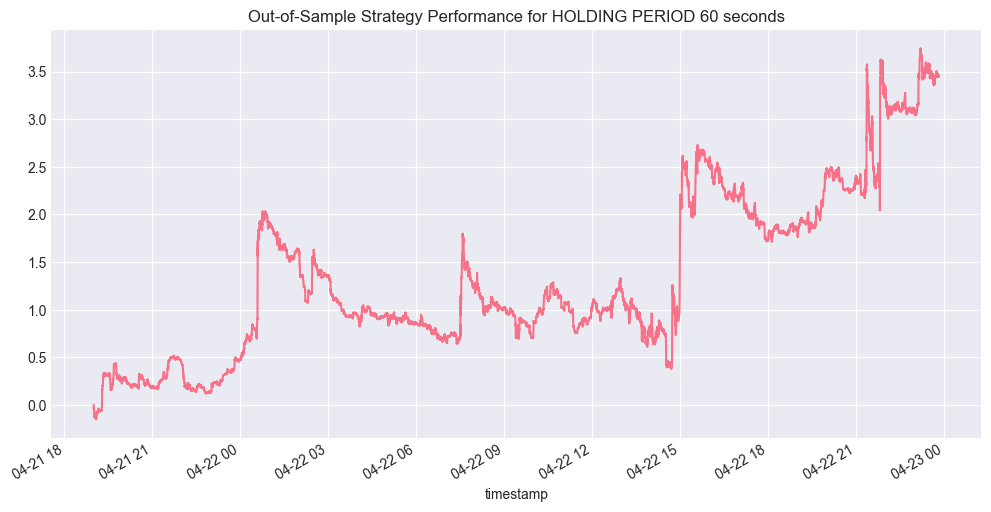

Out-of-Sample Annualized Sharpe Ratio: 0.67


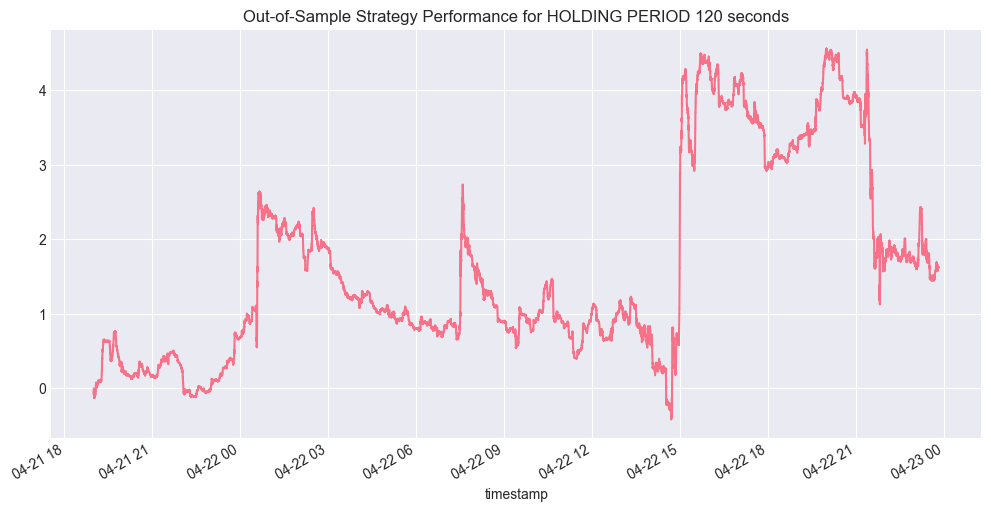

In [25]:
# Perform trading strategy backtest using the alpha signal
# Evaluate performance with different holding periods and calculate Sharpe ratios

backtest_df = pd.DataFrame({
    'alpha_signal': signal_test,
    'actual_return': y_test
})
COST_PER_TRADE = 0.00002
HOLDING_PERIOD = [1, 3, 5, 10, 15, 30, 60, 120]

for h in HOLDING_PERIOD:
    upper_thresh = backtest_df['alpha_signal'].quantile(0.85) # Trade on top 15%
    lower_thresh = backtest_df['alpha_signal'].quantile(0.15) # Trade on bottom 15%
    backtest_df['position'] = 0
    backtest_df.loc[backtest_df['alpha_signal'] > upper_thresh, 'position'] = 1
    backtest_df.loc[backtest_df['alpha_signal'] < lower_thresh, 'position'] = -1


    backtest_df['pnl'] = backtest_df['position'].shift(1) * backtest_df['actual_return'].rolling(window=h).sum().shift(-h)

    trades_taken = (backtest_df['position'] != 0) & (backtest_df['position'].shift(1) == 0)
    backtest_df.loc[trades_taken, 'pnl'] -= COST_PER_TRADE
    backtest_df.fillna(0, inplace=True)


    trading_periods_per_year = 252 * 6.5 * 3600 # (days * hours * seconds) / h
    sharpe_ratio = (backtest_df['pnl'].mean() / backtest_df['pnl'].std()) * np.sqrt(trading_periods_per_year / h)
    print(f"Out-of-Sample Annualized Sharpe Ratio: {sharpe_ratio:.2f}")

    backtest_df['equity_curve'] = backtest_df['pnl'].cumsum()
    backtest_df['equity_curve'].plot(figsize=(12,6), title=f'Out-of-Sample Strategy Performance for HOLDING PERIOD {h} seconds')
    plt.show()